In [1]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#     "duckdb",
#     "matplotlib",
#     "numpy",
#     "pandas",
#     "polars",
#     "seaborn",
# ]
#
# [tool.uv]
# exclude-newer = "2025-07-21T09:47:55.852328281+02:00"
# ///

# GintsEngelen/CICFlowMeter

Checking out https://github.com/GintsEngelen/CICFlowMeter

> This forked repository contains our fixed version of the original CICFlowmeter tool. The improvements were implemented as part of our paper, where we performed an extensive analysis of the CICIDS 2017 dataset and the CICFlowMeter tool.

In [2]:
import duckdb
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
pd.set_option('display.max_rows', None)

In [4]:
data_path = "../data"
date_filter = "v1.1/year=2021/month=01/day=03"

## Label distribution with different CICFlowMeter versions

In [5]:
duckdb.sql(f"""
CREATE OR REPLACE view flows_orig AS
FROM read_csv(
    '{data_path}/cicflowmeter/{date_filter}/*.pcap_Flow.csv',
    hive_partitioning='true');
CREATE OR REPLACE view flows_engelen AS
FROM read_csv(
    '{data_path}/cicflowmeter-gintsengelen/{date_filter}/*.pcap_Flow.csv',
    hive_partitioning='true');
CREATE OR REPLACE view flows_engelen_unlabled AS
FROM read_csv(
    '{data_path}/cicflowmeter-gintsengelen/{date_filter}/202101031400.Flow.csv',
    hive_partitioning='true');
""")

In [6]:
label_count_cicflowmeter = duckdb.sql(f"""
SELECT Label, COUNT(Label) as Count
FROM flows_orig
GROUP BY Label
ORDER BY Count DESC;
""").df()

In [7]:
label_count_engelen = duckdb.sql(f"""
SELECT Label, COUNT(Label) as Count
FROM flows_engelen
GROUP BY Label
ORDER BY Count DESC;
""").df()

In [8]:
label_count_engelenul = duckdb.sql(f"""
SELECT Label, COUNT(Label) as Count
FROM flows_engelen_unlabled
GROUP BY Label
ORDER BY Count DESC;
""").df()

In [9]:
label_count = pd.concat([
    label_count_cicflowmeter.set_index('Label').rename(columns={'Count': 'CICFlowMeter'}),
    label_count_engelen.set_index('Label').rename(columns={'Count': 'CICFlowMeterEngelen'}),
    label_count_engelenul.set_index('Label').rename(columns={'Count': 'CICFlowMeterEngelenUL'}).rename(index={'202101031400.pcap_Flow.csv': 'total'}),
], axis=1).fillna(0).astype(int)
label_count.loc['total'] = label_count.sum(numeric_only=True)
label_count

,CICFlowMeter,CICFlowMeterEngelen,CICFlowMeterEngelenUL
Label,,,
benign,618038,6531834,0
anomalous,604827,5933356,0
suspicious,52710,566741,0
notice,15944,175276,0
total,1291519,13207207,11553361


## Flow features

In [10]:
columns_cicflowmeter = duckdb.sql("""
FROM flows_orig
LIMIT 10;
""").df().columns.values

In [11]:
columns_engelen = duckdb.sql("""
FROM flows_engelen
LIMIT 10;
""").df().columns.values

In [12]:
pd.DataFrame({
    'CICFlowMeter': pd.Series(columns_cicflowmeter),
    'CICFlowMeterEngelen': pd.Series(columns_engelen),
})

,CICFlowMeter,CICFlowMeterEngelen
0,Flow ID,Flow ID
1,Src IP,Src IP
2,Src Port,Src Port
3,Dst IP,Dst IP
4,Dst Port,Dst Port
5,Protocol,Protocol
6,Timestamp,Timestamp
7,Flow Duration,Flow Duration
8,Total Fwd Packet,Total Fwd Packet
9,Total Bwd packets,Total Bwd packets


these features are additionally computed in Engelen's version of CICFlowMeter:

In [13]:
[feature for feature in columns_engelen if feature not in columns_cicflowmeter]

['Fwd RST Flags',
 'Bwd RST Flags',
 'Bwd Act Data Pkts',
 'Bwd Seg Size Min',
 'ICMP Code',
 'ICMP Type',
 'Fwd TCP Retrans. Count',
 'Bwd TCP Retrans. Count',
 'Total TCP Retrans. Count',
 'Total Connection Flow Time']

## Annotations

In [14]:
duckdb.sql(f"""
CREATE OR REPLACE VIEW annotations AS
FROM read_parquet(
    '{data_path}/processed/{date_filter}/annotations.parquet',
    hive_partitioning='true');
""")

In [15]:
duckdb.sql("""
FROM annotations
LIMIT 10;
""").df()

,rule_id,anomaly_id,label,distance_normal,distance_anomalous,heuristic,hough_sensitive,hough_optimal,hough_conservative,gamma_sensitive,...,src_ip,src_port,dst_ip,dst_port,proto,distance,num_detectors,day,month,year
0,0,0,anomalous,2.58585,1.86544,999,True,True,True,True,...,77.27.92.100,5072,202.65.57.232,<NA>,None,0.72041,10,03,01,2021
1,1,1,anomalous,1.76851,1.40868,999,True,False,False,True,...,203.178.149.55,<NA>,206.215.228.128,<NA>,None,0.35983,6,03,01,2021
2,2,1,anomalous,1.76851,1.40868,999,True,False,False,True,...,203.178.149.55,<NA>,204.167.201.110,<NA>,None,0.35983,6,03,01,2021
3,3,2,anomalous,1.80010,1.47920,504,True,True,False,False,...,None,443,163.218.81.24,<NA>,None,0.32090,5,03,01,2021
4,4,3,anomalous,1.45795,1.33231,504,False,False,False,True,...,None,443,163.218.101.211,<NA>,None,0.12564,4,03,01,2021
5,5,3,anomalous,1.45795,1.33231,504,False,False,False,True,...,168.244.34.4,80,163.218.101.211,<NA>,None,0.12564,4,03,01,2021
6,6,4,anomalous,2.15463,1.64727,999,True,True,True,True,...,94.8.39.150,<NA>,None,<NA>,None,0.50736,8,03,01,2021
7,7,4,anomalous,2.15463,1.64727,999,True,True,True,True,...,91.224.236.218,<NA>,None,<NA>,None,0.50736,8,03,01,2021
8,8,5,anomalous,2.76992,2.27783,504,True,False,False,True,...,None,443,163.218.193.161,<NA>,None,0.49209,7,03,01,2021
9,9,6,anomalous,1.64747,1.51014,010,True,True,True,True,...,104.222.116.211,<NA>,None,<NA>,None,0.13733,6,03,01,2021


In [16]:
def count_annotation_features(date_filter, data_path=data_path):
    duckdb.sql(f"""
    WITH annotations AS (
        FROM read_parquet(
            '{data_path}/processed/{date_filter}/annotations.parquet',
            hive_partitioning='true')
    ),
    feature_counts AS (
        SELECT *,
            (CASE WHEN start IS NOT NULL THEN 1 ELSE 0 END +
            CASE WHEN stop IS NOT NULL THEN 1 ELSE 0 END +
            CASE WHEN src_ip IS NOT NULL THEN 1 ELSE 0 END +
            CASE WHEN src_port IS NOT NULL THEN 1 ELSE 0 END +
            CASE WHEN dst_ip IS NOT NULL THEN 1 ELSE 0 END +
            CASE WHEN dst_port IS NOT NULL THEN 1 ELSE 0 END +
            CASE WHEN proto IS NOT NULL THEN 1 ELSE 0 END) as feature_count
        FROM annotations
    )
    SELECT
        feature_count as num_features,
        COUNT(*) as annotation_count
    FROM feature_counts
    GROUP BY feature_count
    ORDER BY feature_count;
    """).df().plot.bar(
        x='num_features',
        y='annotation_count',
        title=f'Number of Features per Annotation {date_filter}',
        xlabel='Number of Features',
        ylabel='Number of Annotations',
        rot=0,
        figsize=(10, 6),
        legend=False,
    )
    plt.show()

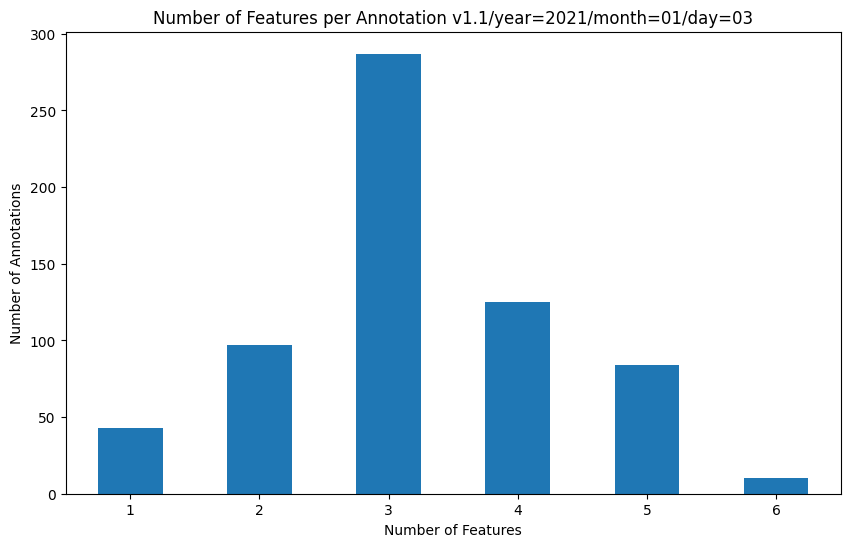

In [17]:
count_annotation_features(date_filter)

## Taxonomies

In [ ]:
duckdb.sql(f"""
CREATE OR REPLACE view cicflowmeter_orig AS
FROM read_parquet(
    '{data_path}/processed/{date_filter}/cicflowmeter_flows.parquet',
    hive_partitioning='true');
CREATE OR REPLACE view cicflowmeter_gintsengelen AS
FROM read_parquet(
    '{data_path}/processed-gintsengelen/{date_filter}/cicflowmeter_flows.parquet',
    hive_partitioning='true');
""")

In [19]:
taxonomies = duckdb.sql("""
WITH orig AS (
    SELECT Taxonomy, COUNT(Taxonomy) as CountOrig
    FROM cicflowmeter_orig
    WHERE Taxonomy IS NOT NULL
    GROUP BY Taxonomy
),
engelen AS (
    SELECT Taxonomy, COUNT(Taxonomy) as CountEngelen
    FROM cicflowmeter_gintsengelen
    WHERE Taxonomy IS NOT NULL
    GROUP BY Taxonomy
)
SELECT
    COALESCE(o.Taxonomy, e.Taxonomy) as Taxonomy,
    COALESCE(o.CountOrig, 0) as CountOrig,
    COALESCE(e.CountEngelen, 0) as CountEngelen
FROM orig o
FULL OUTER JOIN engelen e ON o.Taxonomy = e.Taxonomy
ORDER BY CountOrig DESC, CountEngelen DESC;
""").df()
taxonomies

,Taxonomy,CountOrig,CountEngelen
0,mptmp,1171365,8378566
1,ipv4gretun,72196,930928
2,mptp,59835,410352
3,ptmp,19518,197796
4,ntscSYN,16847,118012
5,mptpla,12373,135184
6,alphfl,10445,108723
7,ptmpHTTP,9944,175396
8,sntscSYN,5624,71428
9,ntscUDPUDPrp,4850,52175


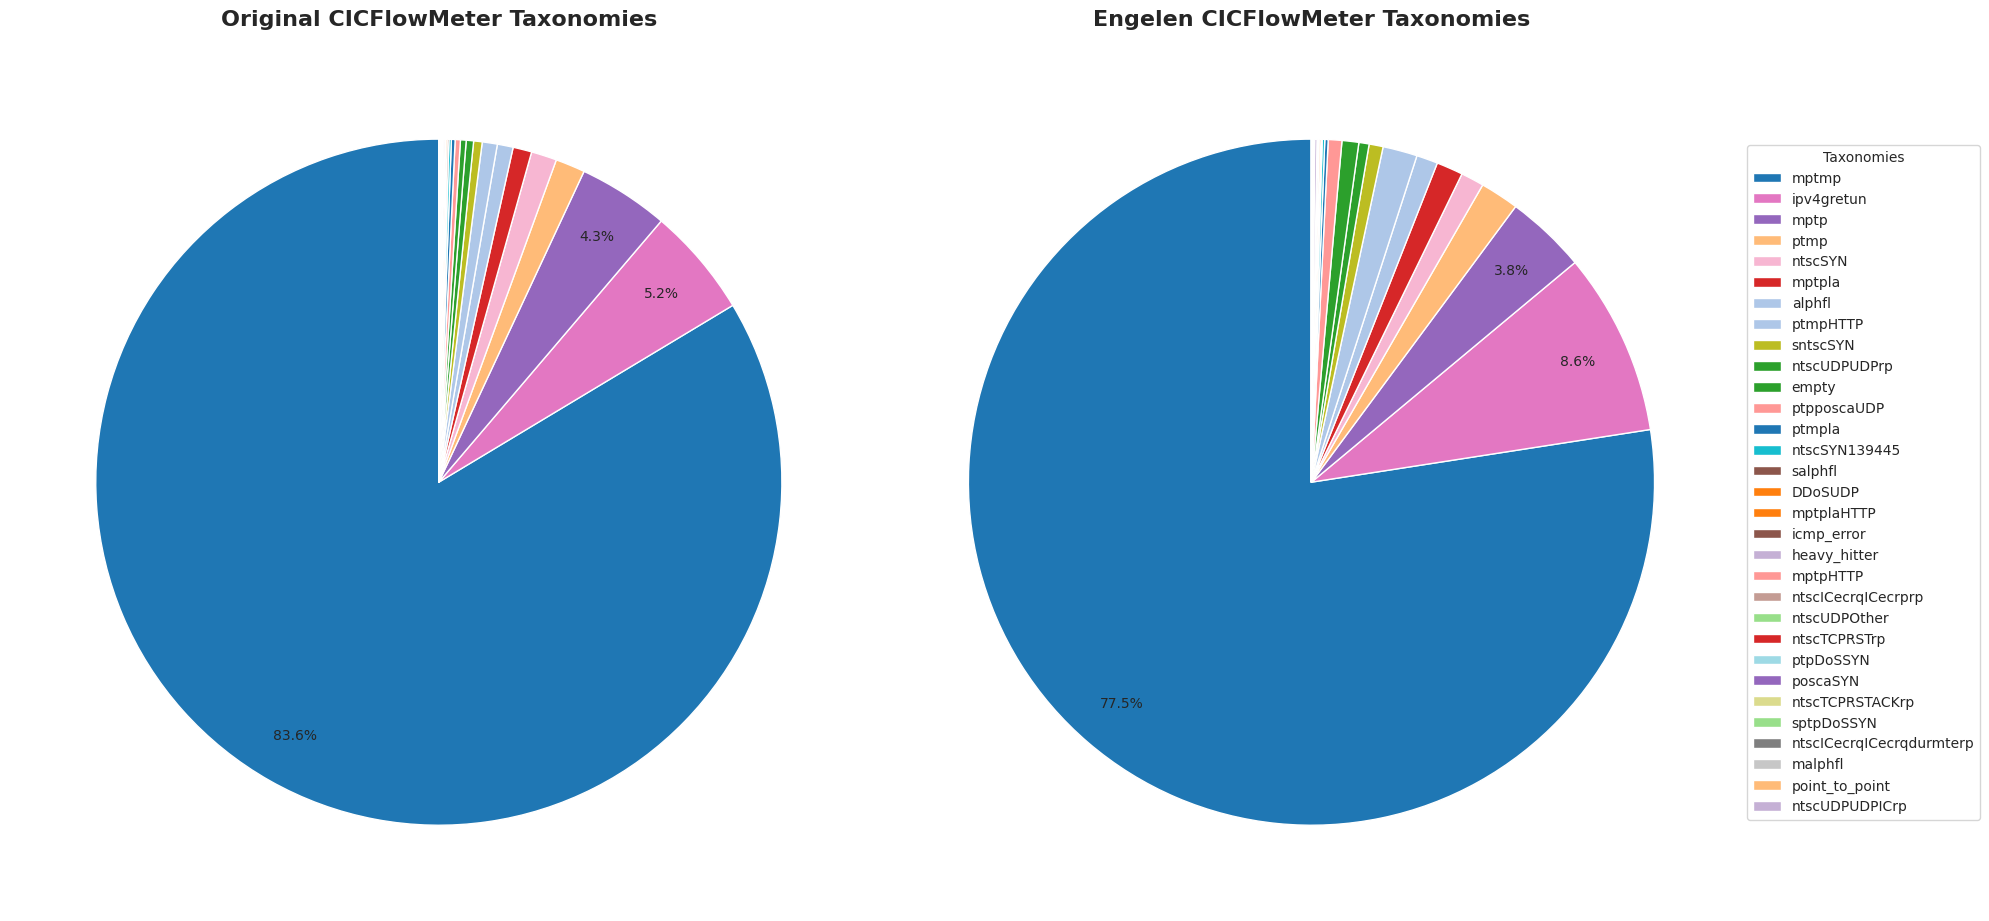

In [20]:
# Set seaborn style for better aesthetics
sns.set_style("whitegrid")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Get all unique taxonomies from both datasets
all_taxonomies = list(set(taxonomies[taxonomies['CountOrig'] > 0]['Taxonomy'].tolist() +
                         taxonomies[taxonomies['CountEngelen'] > 0]['Taxonomy'].tolist()))
# Create a color mapping for all taxonomies
color_palette = sns.color_palette("tab20", len(all_taxonomies))
color_map = dict(zip(all_taxonomies, color_palette))

# Only show labels for slices > 2%
def autopct_func(pct):
    return f'{pct:.1f}%' if pct > 2 else ''

# Original CICFlowMeter pie chart
orig_data = taxonomies[taxonomies['CountOrig'] > 0].copy()
colors1 = [color_map[tax] for tax in orig_data['Taxonomy']]

wedges1, texts1, autotexts1 = ax1.pie(orig_data['CountOrig'],
                                      labels=None,  # Remove labels from pie
                                      autopct=autopct_func,
                                      startangle=90,
                                      colors=colors1,
                                      pctdistance=0.85)
ax1.set_title('Original CICFlowMeter Taxonomies', fontsize=16, fontweight='bold', pad=20)

# Engelen CICFlowMeter pie chart
engelen_data = taxonomies[taxonomies['CountEngelen'] > 0].copy()
colors2 = [color_map[tax] for tax in engelen_data['Taxonomy']]

wedges2, texts2, autotexts2 = ax2.pie(engelen_data['CountEngelen'],
                                      labels=None,  # Remove labels from pie
                                      autopct=autopct_func,
                                      startangle=90,
                                      colors=colors2,
                                      pctdistance=0.85)
ax2.set_title('Engelen CICFlowMeter Taxonomies', fontsize=16, fontweight='bold', pad=20)

# Add legend outside the pie chart
ax2.legend(wedges2, engelen_data['Taxonomy'], title="Taxonomies",
          loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()

## Try anomaly assigment after CICFlowMeter

Instead of splitting the pcap into chunks and then running CICFlowMeter on each chunk, we can run CICFlowMeter on the whole pcap and then assign anomalies to the flows based on the annotations.

In [ ]:
duckdb.sql(f"""
CREATE OR REPLACE TABLE t_annotations AS
SELECT
    *,
    (CASE WHEN start IS NOT NULL THEN 1 ELSE 0 END +
    CASE WHEN stop IS NOT NULL THEN 1 ELSE 0 END +
    CASE WHEN src_ip IS NOT NULL THEN 1 ELSE 0 END +
    CASE WHEN src_port IS NOT NULL THEN 1 ELSE 0 END +
    CASE WHEN dst_ip IS NOT NULL THEN 1 ELSE 0 END +
    CASE WHEN dst_port IS NOT NULL THEN 1 ELSE 0 END +
    CASE WHEN proto IS NOT NULL THEN 1 ELSE 0 END) as feature_count,
    stop - start as duration
FROM annotations
ORDER BY feature_count DESC, duration;
""")

In [22]:
duckdb.sql(f"""
SELECT anomaly_id, label, taxonomy, heuristic, num_detectors, distance, start, stop, src_ip, src_port, dst_ip, dst_port, proto
FROM t_annotations
LIMIT 10;
""").df()

,anomaly_id,label,taxonomy,heuristic,num_detectors,distance,start,stop,src_ip,src_port,dst_ip,dst_port,proto
0,0,notice,alphfl,504,1,-0.413337,1609650300,1609650301,163.218.120.23,<NA>,99.36.148.14,443,tcp
1,134,suspicious,salphfl,999,2,-0.402232,1609650156,1609650172,133.83.143.128,58635,110.179.9.51,30558,None
2,154,suspicious,salphfl,999,2,-0.402232,1609650510,1609650526,133.83.143.128,62403,14.107.43.125,33497,None
3,131,suspicious,salphfl,999,2,-0.402232,1609650000,1609650037,203.178.146.45,5353,120.219.44.71,42233,None
4,131,suspicious,salphfl,999,2,-0.402232,1609650000,1609650037,203.178.146.45,5353,120.219.44.71,36624,None
5,158,suspicious,salphfl,999,2,-0.402232,1609650007,1609650732,163.218.200.230,42592,209.206.73.205,7351,None
6,163,suspicious,mptpla,504,2,-0.402232,1609650008,1609650785,133.83.119.239,35304,188.148.213.245,443,None
7,163,suspicious,mptpla,504,2,-0.402232,1609650008,1609650785,45.163.194.59,52750,188.148.213.245,5938,None
8,165,suspicious,salphfl,504,2,-0.402232,1609650014,1609650825,163.218.43.196,50566,54.188.101.39,443,None
9,165,suspicious,salphfl,504,2,-0.402232,1609650014,1609650825,163.218.43.196,49234,54.188.101.39,443,None


In [23]:
# Create a view with protocol names mapped
duckdb.sql("""
CREATE OR REPLACE VIEW flows_with_protocol_names AS
SELECT *,
    CASE
        WHEN Protocol = 6 THEN 'tcp'
        WHEN Protocol = 17 THEN 'udp'
        WHEN Protocol = 1 THEN 'icmp'
        WHEN Protocol = 2 THEN 'igmp'
        WHEN Protocol = 4 THEN 'ip'
        WHEN Protocol = 41 THEN 'ipv6'
        WHEN Protocol = 58 THEN 'icmpv6'
        WHEN Protocol = 89 THEN 'ospf'
        WHEN Protocol = 132 THEN 'sctp'
        ELSE 'unknown_' || CAST(Protocol AS VARCHAR)
    END as protocol_name
FROM flows_engelen_unlabled;
""")

In [24]:
duckdb.sql(f"""
FROM flows_with_protocol_names
LIMIT 5;
""").df()

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,ICMP Type,Fwd TCP Retrans. Count,Bwd TCP Retrans. Count,Total TCP Retrans. Count,Total Connection Flow Time,Label,day,month,year,protocol_name
0,39.48.158.53-133.69.190.69-8373-50356-6,39.48.158.53,8373,133.69.190.69,50356,6,2021-01-03 05:00:00.098274,967,1,1,...,-1,0,0,0,967,202101031400.pcap_Flow.csv,03,01,2021,tcp
1,171.15.111.232-133.69.190.69-8193-50356-6,171.15.111.232,8193,133.69.190.69,50356,6,2021-01-03 05:00:00.068403,1056,1,1,...,-1,0,0,0,1056,202101031400.pcap_Flow.csv,03,01,2021,tcp
2,218.153.122.59-133.69.190.69-22913-50356-6,218.153.122.59,22913,133.69.190.69,50356,6,2021-01-03 05:00:00.182152,1087,1,1,...,-1,0,0,0,1087,202101031400.pcap_Flow.csv,03,01,2021,tcp
3,36.135.209.81-133.69.190.69-11125-50356-6,36.135.209.81,11125,133.69.190.69,50356,6,2021-01-03 05:00:00.185538,1070,1,1,...,-1,0,0,0,1070,202101031400.pcap_Flow.csv,03,01,2021,tcp
4,14.26.185.179-133.69.190.69-24137-50356-6,14.26.185.179,24137,133.69.190.69,50356,6,2021-01-03 05:00:00.196773,1029,1,1,...,-1,0,0,0,1029,202101031400.pcap_Flow.csv,03,01,2021,tcp


In [25]:
duckdb.sql("""
WITH annotation AS (
    SELECT *
    FROM t_annotations
    ORDER BY feature_count DESC, duration
    LIMIT 1
)
SELECT
    f.*,
    a.anomaly_id,
    a.label as annotation_label,
    a.feature_count
FROM flows_with_protocol_names f
CROSS JOIN annotation a
WHERE
    -- Match time window if specified (convert timestamp to epoch for comparison)
    (a.start IS NULL OR epoch(f."Timestamp") >= a.start) AND
    (a.stop IS NULL OR epoch(f."Timestamp") <= a.stop) AND
    -- Match source IP if specified
    (a.src_ip IS NULL OR f."Src IP" = a.src_ip) AND
    -- Match source port if specified
    (a.src_port IS NULL OR f."Src Port" = a.src_port) AND
    -- Match destination IP if specified
    (a.dst_ip IS NULL OR f."Dst IP" = a.dst_ip) AND
    -- Match destination port if specified
    (a.dst_port IS NULL OR f."Dst Port" = a.dst_port) AND
    -- Match protocol if specified
    (a.proto IS NULL OR f.protocol_name = a.proto)
LIMIT 10;
""").df()

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Total TCP Retrans. Count,Total Connection Flow Time,Label,day,month,year,protocol_name,anomaly_id,annotation_label,feature_count
0,163.218.120.23-99.36.148.14-63862-443-6,163.218.120.23,63862,99.36.148.14,443,6,2021-01-03 05:05:00.418809,92770045,290,964,...,8,92770045,202101031400.pcap_Flow.csv,03,01,2021,tcp,0,notice,6


In [26]:
duckdb.sql("""
CREATE OR REPLACE VIEW flows_with_annotations AS
WITH flow_annotation_matches AS (
    SELECT
        f.*,
        a.anomaly_id,
        a.label as annotation_label,
        a.taxonomy,
        a.heuristic,
        a.num_detectors,
        a.distance,
        a.feature_count,
        a.duration,
        -- Rank annotations by specificity (most features first, then shortest duration)
        ROW_NUMBER() OVER (
            PARTITION BY f."Flow ID"
            ORDER BY a.feature_count DESC, a.duration ASC NULLS LAST
        ) as annotation_rank
    FROM flows_with_protocol_names f
    JOIN t_annotations a ON
        -- Match time window if specified
        (a.start IS NULL OR epoch(f."Timestamp") >= a.start) AND
        (a.stop IS NULL OR epoch(f."Timestamp") <= a.stop) AND
        -- Match source IP if specified
        (a.src_ip IS NULL OR f."Src IP" = a.src_ip) AND
        -- Match source port if specified
        (a.src_port IS NULL OR f."Src Port" = a.src_port) AND
        -- Match destination IP if specified
        (a.dst_ip IS NULL OR f."Dst IP" = a.dst_ip) AND
        -- Match destination port if specified
        (a.dst_port IS NULL OR f."Dst Port" = a.dst_port) AND
        -- Match protocol if specified
        (a.proto IS NULL OR f.protocol_name = a.proto)
),
best_annotations AS (
    SELECT *
    FROM flow_annotation_matches
    WHERE annotation_rank = 1
)
SELECT
    f.* EXCLUDE ("Label"),
    -- Override Label: Use annotation label if available, otherwise 'benign'
    COALESCE(b.annotation_label, 'benign') as "Label",
    b.anomaly_id,
    b.feature_count,
    b.taxonomy,
    b.heuristic,
    b.num_detectors,
    b.distance,
FROM flows_with_protocol_names f
LEFT JOIN best_annotations b ON f."Flow ID" = b."Flow ID";
""")

In [27]:
duckdb.sql("""
SELECT
    "Flow ID",
    "Src IP",
    "Src Port",
    "Dst IP",
    "Dst Port",
    protocol_name,
    "Label",
    anomaly_id,
    feature_count,
    taxonomy,
    heuristic,
    num_detectors,
    distance
FROM flows_with_annotations
LIMIT 10;
""").df()

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,protocol_name,Label,anomaly_id,feature_count,taxonomy,heuristic,num_detectors,distance
0,39.48.158.53-133.69.190.69-8373-50356-6,39.48.158.53,8373,133.69.190.69,50356,tcp,anomalous,73,2,mptp,010,6,0.40959
1,171.15.111.232-133.69.190.69-8193-50356-6,171.15.111.232,8193,133.69.190.69,50356,tcp,anomalous,73,2,mptp,010,6,0.40959
2,218.153.122.59-133.69.190.69-22913-50356-6,218.153.122.59,22913,133.69.190.69,50356,tcp,anomalous,73,2,mptp,010,6,0.40959
3,36.135.209.81-133.69.190.69-11125-50356-6,36.135.209.81,11125,133.69.190.69,50356,tcp,anomalous,73,2,mptp,010,6,0.40959
4,14.26.185.179-133.69.190.69-24137-50356-6,14.26.185.179,24137,133.69.190.69,50356,tcp,anomalous,73,2,mptp,010,6,0.40959
5,36.143.247.24-133.69.190.69-11777-50356-6,36.143.247.24,11777,133.69.190.69,50356,tcp,anomalous,73,2,mptp,010,6,0.40959
6,119.139.233.85-133.69.190.69-12165-50356-6,119.139.233.85,12165,133.69.190.69,50356,tcp,anomalous,73,2,mptp,010,6,0.40959
7,220.172.236.231-133.69.190.69-53077-50356-6,220.172.236.231,53077,133.69.190.69,50356,tcp,anomalous,73,2,mptp,010,6,0.40959
8,39.48.158.53-133.69.190.69-8373-50356-6,39.48.158.53,8373,133.69.190.69,50356,tcp,anomalous,73,2,mptp,010,6,0.40959
9,219.122.92.108-133.69.190.69-4681-50356-6,219.122.92.108,4681,133.69.190.69,50356,tcp,anomalous,73,2,mptp,010,6,0.40959


In [28]:
label_count_engelenul = duckdb.sql(f"""
SELECT Label, COUNT(Label) as Count
FROM flows_with_annotations
GROUP BY Label
ORDER BY Count DESC;
""").df()

In [29]:
label_count = pd.concat([
    label_count_cicflowmeter.set_index('Label').rename(columns={'Count': 'Pcap Split, CICFlowMeter'}),
    label_count_engelen.set_index('Label').rename(columns={'Count': 'Pcap Split, CICFlowMeter Engelen'}),
    label_count_engelenul.set_index('Label').rename(columns={'Count': 'CICFlowMeter Engelen, Anomaly Assigment'}),
], axis=1).fillna(0).astype(int)
label_count.loc['total'] = label_count.sum(numeric_only=True)
label_count

,"Pcap Split, CICFlowMeter","Pcap Split, CICFlowMeter Engelen","CICFlowMeter Engelen, Anomaly Assigment"
Label,,,
benign,618038,6531834,10227241
anomalous,604827,5933356,692757
suspicious,52710,566741,201893
notice,15944,175276,431470
total,1291519,13207207,11553361


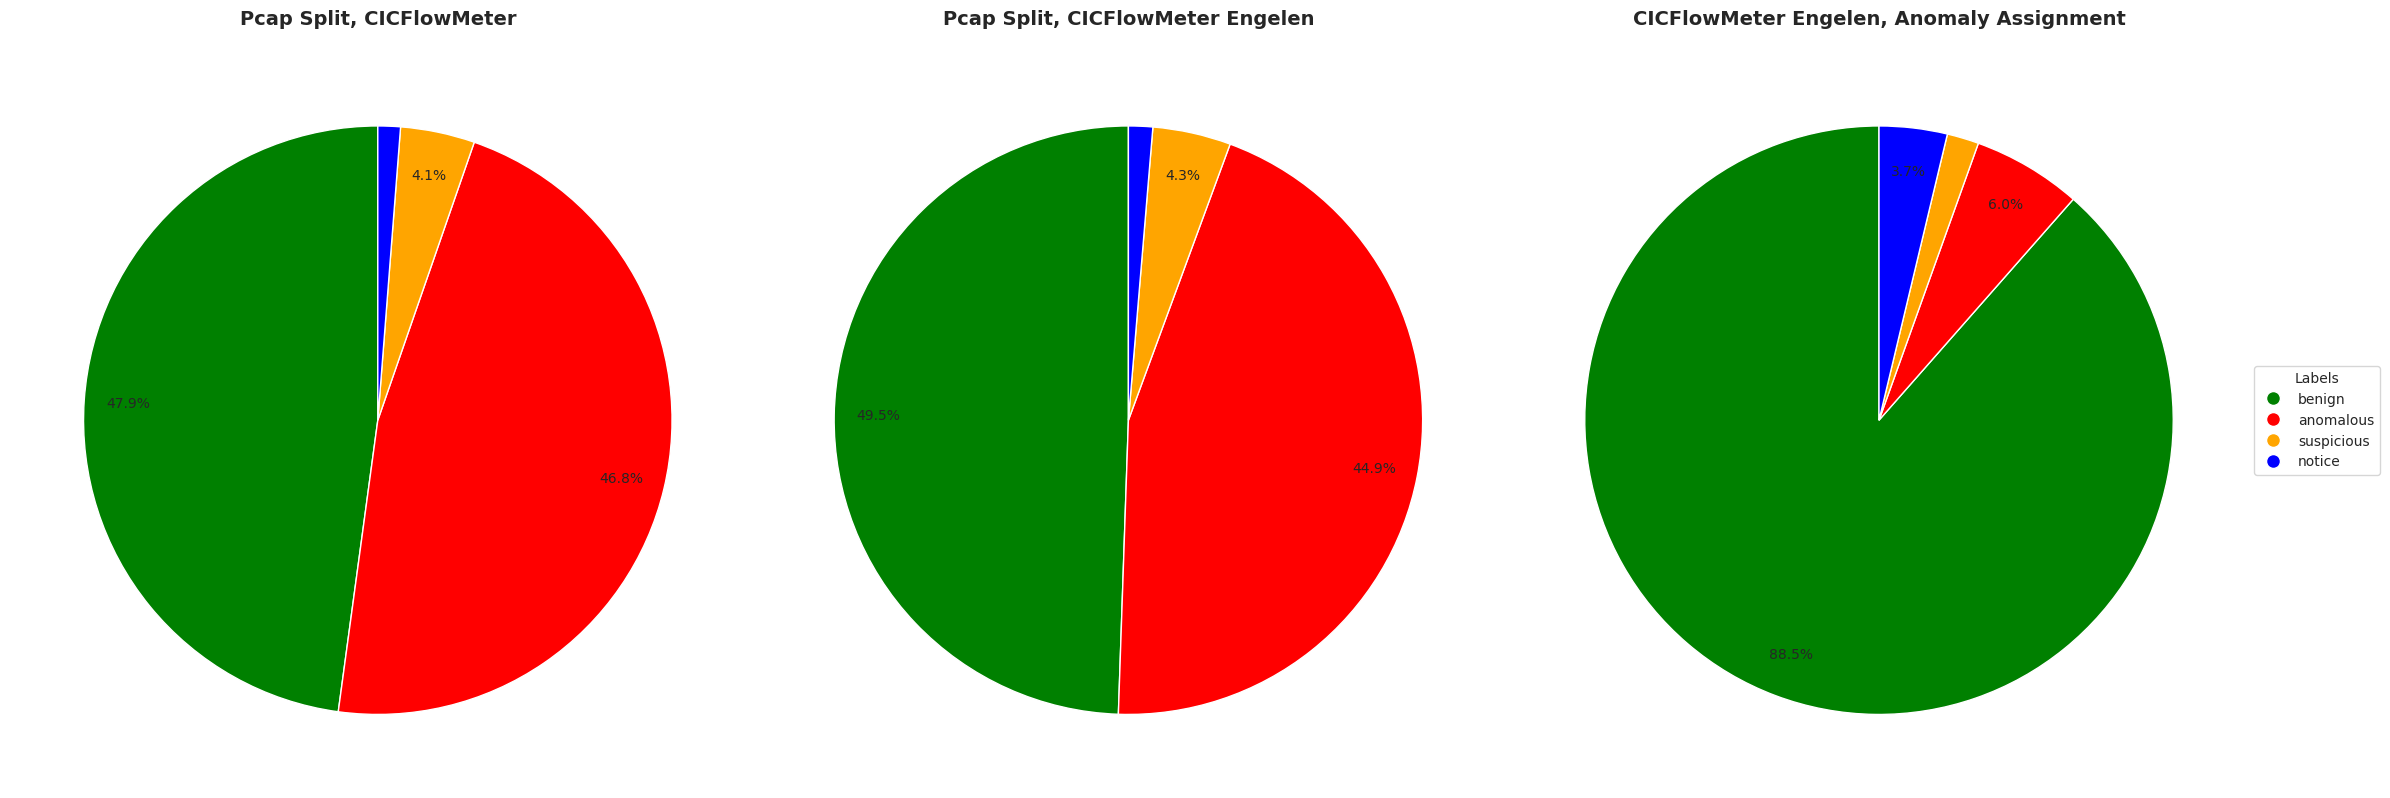

In [30]:
# Set seaborn style for better aesthetics
sns.set_style("whitegrid")

# Create subplots for the three datasets
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Get all unique labels across all datasets
all_labels = set()
for col in label_count.columns:
    all_labels.update(label_count[label_count[col] > 0].index.tolist())
all_labels.discard('total')  # Remove total row from labels

# Create a specific color mapping
color_map = {}
for label in all_labels:
    label_lower = label.lower()
    if 'benign' in label_lower:
        color_map[label] = 'green'
    elif 'notice' in label_lower:
        color_map[label] = 'blue'
    elif 'suspicious' in label_lower:
        color_map[label] = 'orange'
    elif 'anomal' in label_lower:
        color_map[label] = 'red'
    else:
        color_map[label] = 'gray'  # fallback color

# Function to format percentages (only show if > 2%)
def autopct_func(pct):
    return f'{pct:.1f}%' if pct > 2 else ''

# Plot 1: Pcap Split, CICFlowMeter
data1 = label_count[label_count['Pcap Split, CICFlowMeter'] > 0]['Pcap Split, CICFlowMeter']
data1 = data1.drop('total', errors='ignore')
colors1 = [color_map[label] for label in data1.index]

wedges1, texts1, autotexts1 = axes[0].pie(data1.values,
                                          labels=None,
                                          autopct=autopct_func,
                                          startangle=90,
                                          colors=colors1,
                                          pctdistance=0.85)
axes[0].set_title('Pcap Split, CICFlowMeter', fontsize=14, fontweight='bold', pad=20)

# Plot 2: Pcap Split, CICFlowMeter Engelen
data2 = label_count[label_count['Pcap Split, CICFlowMeter Engelen'] > 0]['Pcap Split, CICFlowMeter Engelen']
data2 = data2.drop('total', errors='ignore')
colors2 = [color_map[label] for label in data2.index]

wedges2, texts2, autotexts2 = axes[1].pie(data2.values,
                                          labels=None,
                                          autopct=autopct_func,
                                          startangle=90,
                                          colors=colors2,
                                          pctdistance=0.85)
axes[1].set_title('Pcap Split, CICFlowMeter Engelen', fontsize=14, fontweight='bold', pad=20)

# Plot 3: CICFlowMeter Engelen, Anomaly Assignment
data3 = label_count[label_count['CICFlowMeter Engelen, Anomaly Assigment'] > 0]['CICFlowMeter Engelen, Anomaly Assigment']
data3 = data3.drop('total', errors='ignore')
colors3 = [color_map[label] for label in data3.index]

wedges3, texts3, autotexts3 = axes[2].pie(data3.values,
                                          labels=None,
                                          autopct=autopct_func,
                                          startangle=90,
                                          colors=colors3,
                                          pctdistance=0.85)
axes[2].set_title('CICFlowMeter Engelen, Anomaly Assignment', fontsize=14, fontweight='bold', pad=20)

# Add a shared legend with color coding
legend_elements = []
for label in data3.index:
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                                     markerfacecolor=color_map[label], markersize=10, label=label))

axes[2].legend(handles=legend_elements, title="Labels",
              loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()

In [31]:
taxonomies = duckdb.sql("""
WITH orig AS (
    SELECT Taxonomy, COUNT(Taxonomy) as CountOrig
    FROM cicflowmeter_orig
    WHERE Taxonomy IS NOT NULL
    GROUP BY Taxonomy
),
engelen AS (
    SELECT Taxonomy, COUNT(Taxonomy) as CountEngelen
    FROM cicflowmeter_gintsengelen
    WHERE Taxonomy IS NOT NULL
    GROUP BY Taxonomy
),
annotated AS (
    SELECT taxonomy as Taxonomy, COUNT(taxonomy) as CountAnnotated
    FROM flows_with_annotations
    WHERE taxonomy IS NOT NULL
    GROUP BY taxonomy
)
SELECT
    COALESCE(o.Taxonomy, e.Taxonomy, a.Taxonomy) as Taxonomy,
    COALESCE(o.CountOrig, 0) as CountOrig,
    COALESCE(e.CountEngelen, 0) as CountEngelen,
    COALESCE(a.CountAnnotated, 0) as CountEngelenAnnotatedFlow
FROM orig o
FULL OUTER JOIN engelen e ON o.Taxonomy = e.Taxonomy
FULL OUTER JOIN annotated a ON COALESCE(o.Taxonomy, e.Taxonomy) = a.Taxonomy
ORDER BY CountOrig DESC, CountEngelen DESC, CountEngelenAnnotatedFlow DESC;
""").df()
taxonomies

,Taxonomy,CountOrig,CountEngelen,CountEngelenAnnotatedFlow
0,mptmp,1171365,8378566,411957
1,ipv4gretun,72196,930928,16
2,mptp,59835,410352,28962
3,ptmp,19518,197796,50729
4,ntscSYN,16847,118012,113657
5,mptpla,12373,135184,70439
6,alphfl,10445,108723,92948
7,ptmpHTTP,9944,175396,65
8,sntscSYN,5624,71428,399504
9,ntscUDPUDPrp,4850,52175,48491


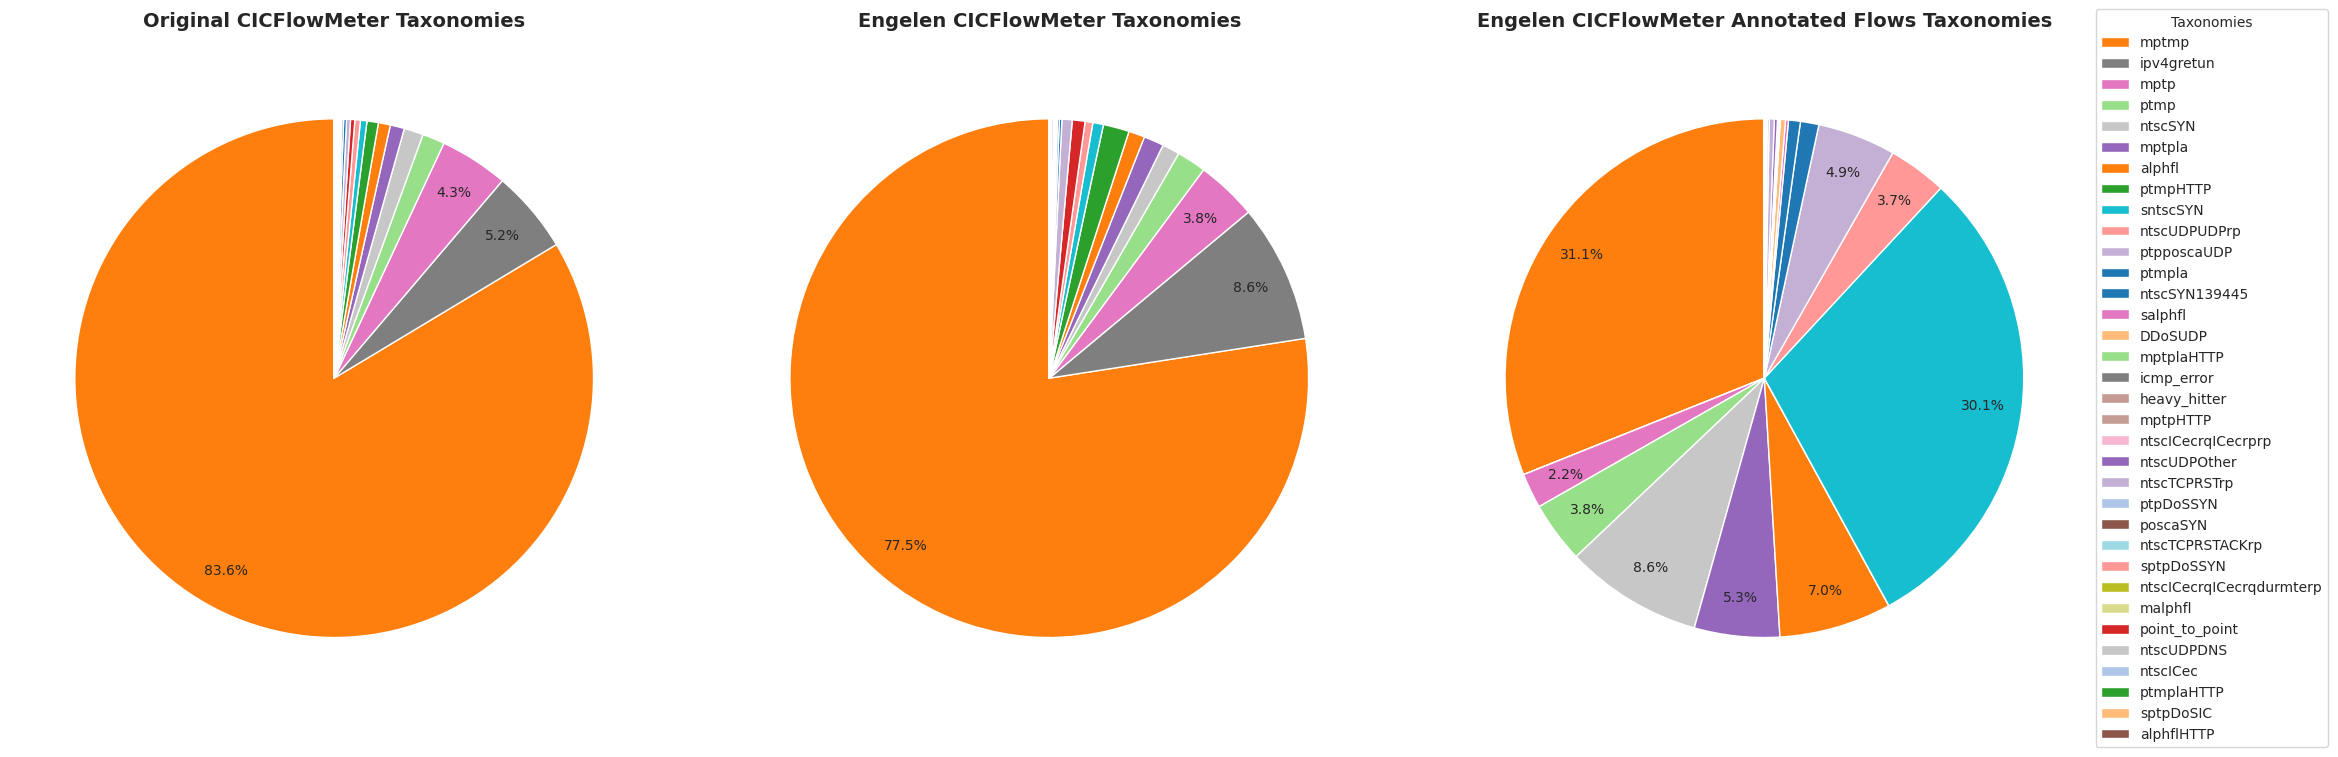

In [32]:
# Set seaborn style for better aesthetics
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Get all unique taxonomies from all three datasets
all_taxonomies = set()
for col in ['CountOrig', 'CountEngelen', 'CountEngelenAnnotatedFlow']:
    all_taxonomies.update(taxonomies[taxonomies[col] > 0]['Taxonomy'].tolist())

# Create a color mapping for all taxonomies
color_palette = sns.color_palette("tab20", len(all_taxonomies))
color_map = dict(zip(all_taxonomies, color_palette))

# Only show labels for slices > 2%
def autopct_func(pct):
    return f'{pct:.1f}%' if pct > 2 else ''

# Plot 1: Original CICFlowMeter
orig_data = taxonomies[taxonomies['CountOrig'] > 0].copy()
colors1 = [color_map[tax] for tax in orig_data['Taxonomy']]

wedges1, texts1, autotexts1 = axes[0].pie(orig_data['CountOrig'],
                                          labels=None,
                                          autopct=autopct_func,
                                          startangle=90,
                                          colors=colors1,
                                          pctdistance=0.85)
axes[0].set_title('Original CICFlowMeter Taxonomies', fontsize=14, fontweight='bold', pad=20)

# Plot 2: Engelen CICFlowMeter
engelen_data = taxonomies[taxonomies['CountEngelen'] > 0].copy()
colors2 = [color_map[tax] for tax in engelen_data['Taxonomy']]

wedges2, texts2, autotexts2 = axes[1].pie(engelen_data['CountEngelen'],
                                          labels=None,
                                          autopct=autopct_func,
                                          startangle=90,
                                          colors=colors2,
                                          pctdistance=0.85)
axes[1].set_title('Engelen CICFlowMeter Taxonomies', fontsize=14, fontweight='bold', pad=20)

# Plot 3: Flows with Annotations
annotated_data = taxonomies[taxonomies['CountEngelenAnnotatedFlow'] > 0].copy()
colors3 = [color_map[tax] for tax in annotated_data['Taxonomy']]

wedges3, texts3, autotexts3 = axes[2].pie(annotated_data['CountEngelenAnnotatedFlow'],
                                          labels=None,
                                          autopct=autopct_func,
                                          startangle=90,
                                          colors=colors3,
                                          pctdistance=0.85)
axes[2].set_title('Engelen CICFlowMeter Annotated Flows Taxonomies', fontsize=14, fontweight='bold', pad=20)

# Add legend outside the pie chart
axes[2].legend(wedges3, annotated_data['Taxonomy'], title="Taxonomies",
              loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()

In [33]:
feature_count = duckdb.sql("""
SELECT feature_count, COUNT(feature_count) as count
FROM flows_with_annotations
WHERE feature_count IS NOT NULL
GROUP BY feature_count
ORDER BY feature_count;
""").df()
feature_count

,feature_count,count
0,1,331481
1,2,158495
2,3,628307
3,4,96376
4,5,111434
5,6,27


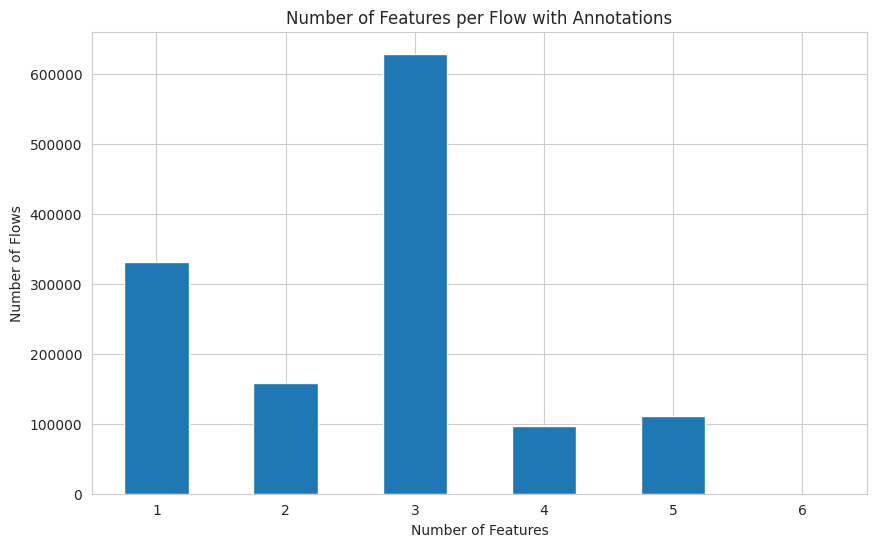

In [34]:
feature_count.plot.bar(
    x='feature_count',
    y='count',
    title='Number of Features per Flow with Annotations',
    xlabel='Number of Features',
    ylabel='Number of Flows',
    rot=0,
    figsize=(10, 6),
    legend=False,
)
plt.show()

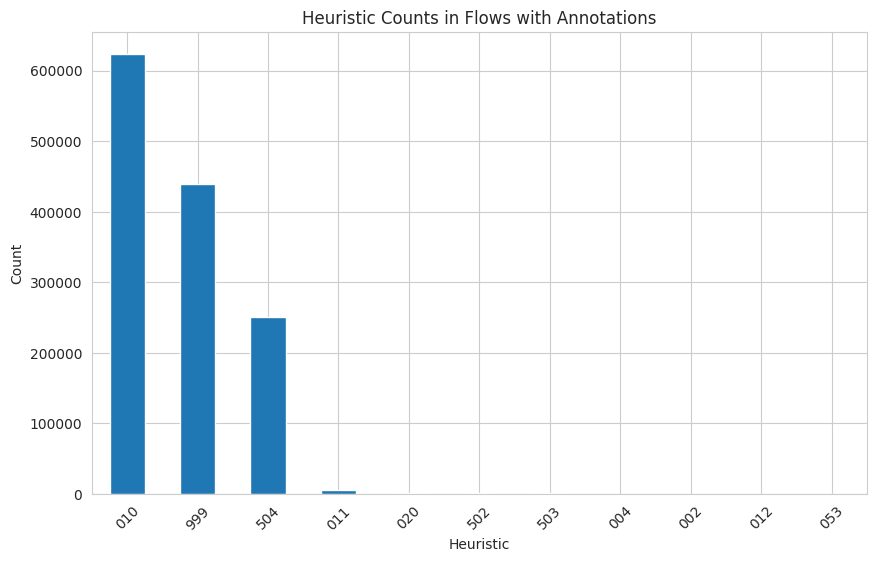

In [35]:
duckdb.sql("""
SELECT heuristic, COUNT(heuristic) as count
FROM flows_with_annotations
WHERE heuristic IS NOT NULL
GROUP BY heuristic
ORDER BY count DESC;
""").df().plot.bar(
    x='heuristic',
    y='count',
    title='Heuristic Counts in Flows with Annotations',
    xlabel='Heuristic',
    ylabel='Count',
    rot=45,
    figsize=(10, 6),
    legend=False,
)
plt.show()